In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.ticker import LinearLocator
import napari
from skimage.transform import radon, resize

from skimage.transform import iradon, iradon_sart
from skimage.metrics import structural_similarity as ssim
from scipy.optimize import curve_fit
from functions import (  # self defined (somewhat)
    generate_num_projections,
    generate_sparse_sinogram,
    order_angles_golden_ratio,
    modified_sart_plus_tv,
    add_salt_pepper,
    add_gaussian_noise,
    calculate_ssim,
    calculate_mse,
    iterative_sart,
    pad_image_square,
)
from skimage.data import shepp_logan_phantom
from skimage import io

/home/msmith693/dev/repos/tomography/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(256, 256)
0.06045257061709114


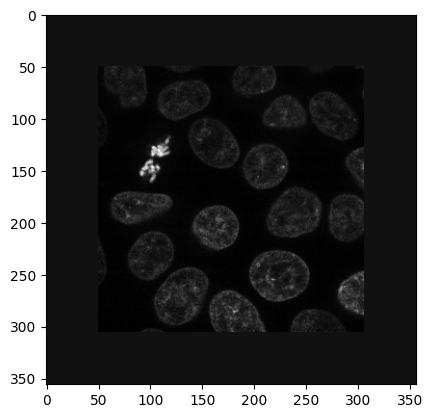

In [ ]:
from skimage import exposure

img = io.imread("../images/cells.tif")[28, :, :]
# img = exposure.equalize_hist(img)

img = exposure.adjust_gamma(img, 1.5)
print(img.shape)
padding_width = 50
background = img.mean()
print(background)


plt.imshow(img, cmap="grey")
plt.imshow(padded_img, cmap="grey")

In [ ]:
from skimage import exposure, filters

img = io.imread("../images/cells.tif")
images = []
for i in range(img.shape[0]):
    img_slice = img[i, :, :]
    # pad image to remove circle artefact
    pad_width = 50
    padded_img = pad_image_square(img_slice, pad_width)
    reconstructed = modified_sart_plus_tv(
        generate_sparse_sinogram(padded_img, 50),
        theta=generate_num_projections(50),
        weight=0.001,
        iterations=15,
    )

    cropped_final_img = reconstructed[
        pad_width : reconstructed.shape[0] - pad_width,
        pad_width : reconstructed.shape[1] - pad_width,
    ]
    # sobel_img = filters.sobel(reconstructed_img)
    images.append(cropped_final_img)

reconstructed_volumetric_img = np.stack(images, axis=0)
print(reconstructed_volumetric_img.shape)
# plt.imshow(reconstructed_img ,cmap='grey')

/home/msmith693/dev/repos/tomography/venv/lib/python3.12/site-packages/skimage/transform/radon_transform.py:74: UserWarning: Radon transform: image must be zero outside the reconstruction circle
  warn(


In [ ]:
viewer = napari.Viewer()
viewer.add_image(img, name="cells_original")
viewer.add_image(reconstructed_volumetric_img, name="cells_reconstructed")
napari.run()

: 